In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


data = pd.read_csv("../data_&_analysis/reduced.csv")

data = data[data['text'].notna()]
data = data[data['label'].notna()]

print("Size of dataset: ", len(data))

Size of dataset:  22975


In [ ]:
# mapping into labels

mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4


data['label'] = data['label'].map(mapped_dict)

print(len(data[data['label']==0]))
print(len(data[data['label']==1]))
print(len(data[data['label']==2]))
print(len(data[data['label']==3]))

def plot_confusion_matrix(Y, Y_pred, title, target_labels):
    matrix = metrics.confusion_matrix(Y, Y_pred, labels=target_labels)
    matrix_df = pd.DataFrame(matrix, columns=np.unique(target_labels), index=np.unique(target_labels))
    f, ax = plt.subplots(figsize=(10,5))
    ax = sns.heatmap(matrix_df, annot=True, fmt="g", cmap = "OrRd")

    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Real values")
    ax.xaxis.set_ticklabels(target_labels)
    ax.yaxis.set_ticklabels(target_labels)
    
    plt.title(title)
    plt.show()


/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:54:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      5971
           1       0.74      0.86      0.80      5663
           2       0.86      0.63      0.73      2686
           3       0.88      0.73      0.80      4060

    accuracy                           0.80     18380
   macro avg       0.82      0.78      0.79     18380
weighted avg       0.81      0.80      0.80     18380

Test set results:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      1492
           1       0.69      0.81      0.75      1416
           2       0.76      0.54      0.63       672
           3       0.77      0.65      0.70      1015

    accuracy                           0.74      4595
   macro avg       0.75      0.71      0.72      4595
weighted avg       0.75      0.74      0.74      4595



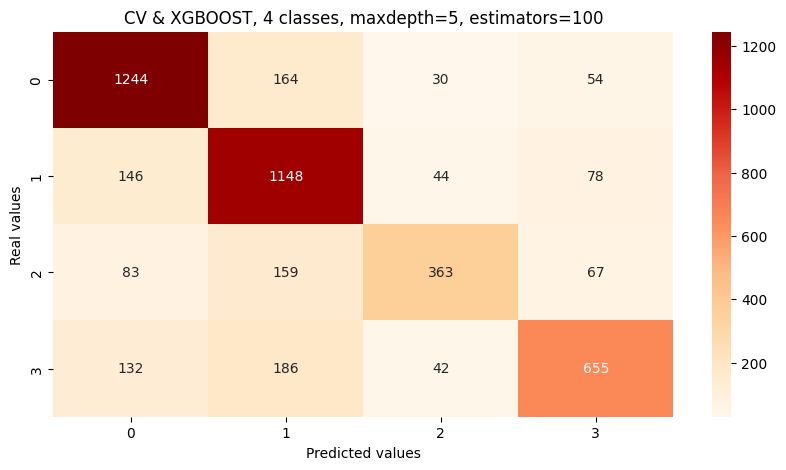

In [3]:
#count vectorizer, then XGB, 4 classes

pipeline = Pipeline([
    ('cnt', CountVectorizer()),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test))
plot_confusion_matrix(Y_test,Y_pred_test, "CV & XGBOOST, 4 classes, maxdepth=5, estimators=100", [0,1,2,3])


/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:55:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5971
           1       0.94      0.99      0.96      5663
           2       0.99      0.92      0.96      2686
           3       0.98      0.96      0.97      4060

    accuracy                           0.97     18380
   macro avg       0.97      0.96      0.97     18380
weighted avg       0.97      0.97      0.97     18380

Test set results:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1492
           1       0.75      0.84      0.79      1416
           2       0.78      0.59      0.67       672
           3       0.81      0.73      0.77      1015

    accuracy                           0.78      4595
   macro avg       0.78      0.75      0.76      4595
weighted avg       0.78      0.78      0.78      4595



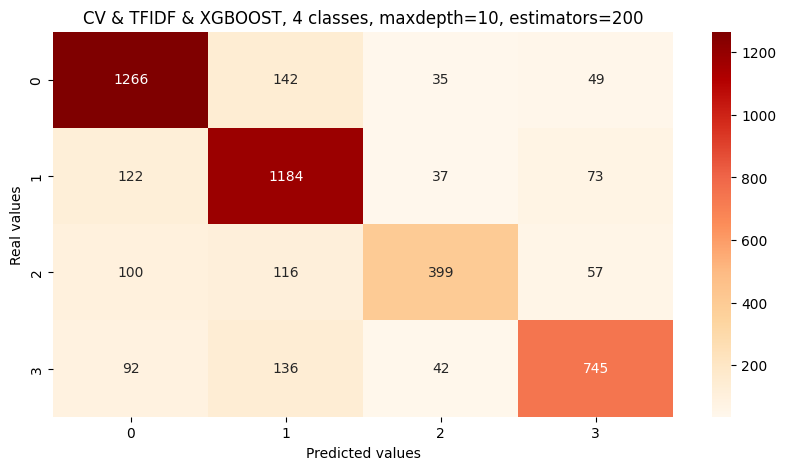

In [4]:
#count & tfidf vectorizer combined, then XGB, 4 classes

pipeline = Pipeline([
    ('cnt', CountVectorizer()), 
    ('tfid', TfidfTransformer()),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=10,
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test))
plot_confusion_matrix(Y_test,Y_pred_test, "CV & TFIDF & XGBOOST, 4 classes, maxdepth=10, estimators=200", [0,1,2,3])

/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:07:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      5971
           1       0.75      0.87      0.81      5663
           2       0.88      0.66      0.76      2686
           3       0.87      0.75      0.80      4060

    accuracy                           0.82     18380
   macro avg       0.83      0.79      0.81     18380
weighted avg       0.82      0.82      0.82     18380

Test set results:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      1492
           1       0.70      0.82      0.76      1416
           2       0.72      0.56      0.63       672
           3       0.81      0.68      0.74      1015

    accuracy                           0.75      4595
   macro avg       0.76      0.72      0.73      4595
weighted avg       0.76      0.75      0.75      4595



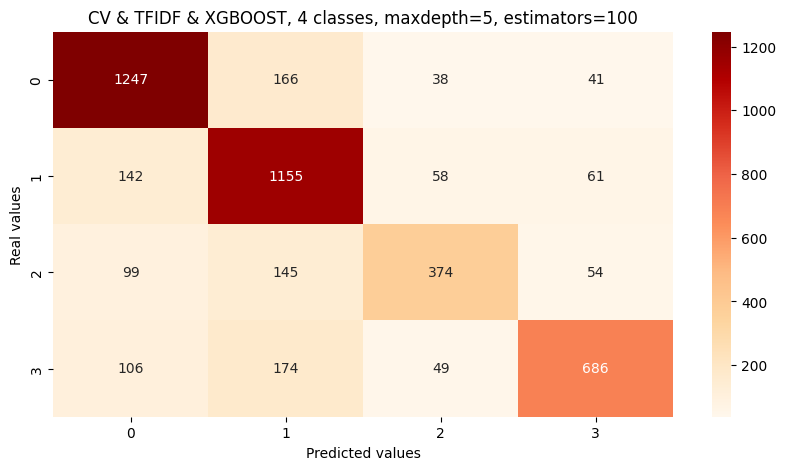

In [5]:
#count & tfidf vectorizer combined, then XGB, 4 classes

pipeline = Pipeline([
    ('cnt', CountVectorizer()), 
    ('tfid', TfidfTransformer()),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test))
plot_confusion_matrix(Y_test,Y_pred_test, "CV & TFIDF & XGBOOST, 4 classes, maxdepth=5, estimators=100", [0,1,2,3])

/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:19:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5970
           1       0.95      0.99      0.97      5663
           2       1.00      0.96      0.98       654
           3       1.00      0.95      0.98      1177
           4       1.00      0.96      0.98       856
           5       1.00      0.98      0.99       657
           6       1.00      0.97      0.98       718
           7       0.99      0.96      0.97      2158
           8       1.00      0.97      0.99       320
           9       1.00      1.00      1.00       207

    accuracy                           0.98     18380
   macro avg       0.99      0.97      0.98     18380
weighted avg       0.98      0.98      0.98     18380

Test set results:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83      1493
           1       0.71      0.86      0.78      1416
           2       0.73      0.25     

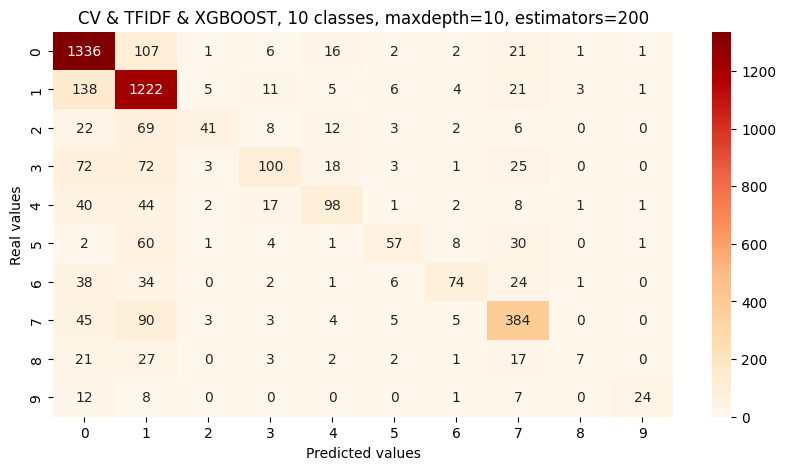

In [6]:
data = pd.read_csv("../data_&_analysis/reduced.csv")

data = data[data['text'].notna()]
data = data[data['label'].notna()]

mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 3,
    "crime": 4,
    
    "science": 5,
    "psychology": 6,
    "history": 7,
    "travel": 8,
    "sports": 9
}
class_number = 10

data['label'] = data['label'].map(mapped_dict)

#count & tfidf vectorizer combined, then XGB, all 10 classes

pipeline = Pipeline([
    ('cnt', CountVectorizer()), 
    ('tfid', TfidfTransformer()),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=10,
        n_estimators=200,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test))
plot_confusion_matrix(Y_test,Y_pred_test, "CV & TFIDF & XGBOOST, 10 classes, maxdepth=10, estimators=200", [0,1,2,3,4,5,6,7,8,9])

/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:13:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      5970
           1       0.74      0.90      0.81      5663
           2       0.98      0.61      0.75       654
           3       0.93      0.60      0.73      1177
           4       0.88      0.71      0.79       856
           5       0.98      0.69      0.81       657
           6       0.99      0.69      0.81       718
           7       0.90      0.75      0.82      2158
           8       0.98      0.52      0.68       320
           9       0.99      0.85      0.92       207

    accuracy                           0.82     18380
   macro avg       0.92      0.72      0.80     18380
weighted avg       0.84      0.82      0.82     18380

Test set results:
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      1493
           1       0.64      0.84      0.73      1416
           2       0.66      0.25     

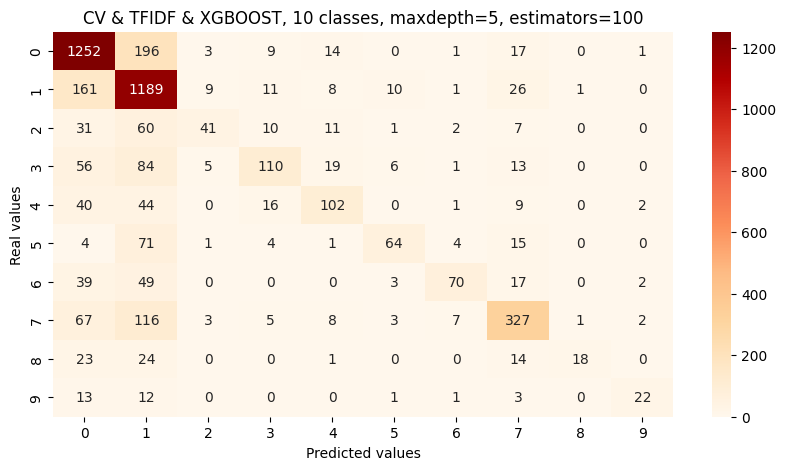

In [ ]:
#count & tfidf vectorizer combined, then XGB, all 10 classes

pipeline = Pipeline([
    ('cnt', CountVectorizer()), 
    ('tfid', TfidfTransformer()),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test))
plot_confusion_matrix(Y_test,Y_pred_test, "CV & TFIDF & XGBOOST, 10 classes, maxdepth=5, estimators=100", [0,1,2,3,4,5,6,7,8,9])

/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:17:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      5970
           1       0.73      0.90      0.81      5663
           2       0.96      0.59      0.73       654
           3       0.93      0.57      0.71      1177
           4       0.87      0.71      0.78       856
           5       0.97      0.68      0.80       657
           6       0.97      0.65      0.78       718
           7       0.87      0.73      0.80      2158
           8       0.97      0.55      0.70       320
           9       0.99      0.75      0.85       207

    accuracy                           0.81     18380
   macro avg       0.91      0.70      0.78     18380
weighted avg       0.83      0.81      0.81     18380

Test set results:
              precision    recall  f1-score   support

           0       0.73      0.83      0.78      1493
           1       0.62      0.83      0.71      1416
           2       0.69      0.25     

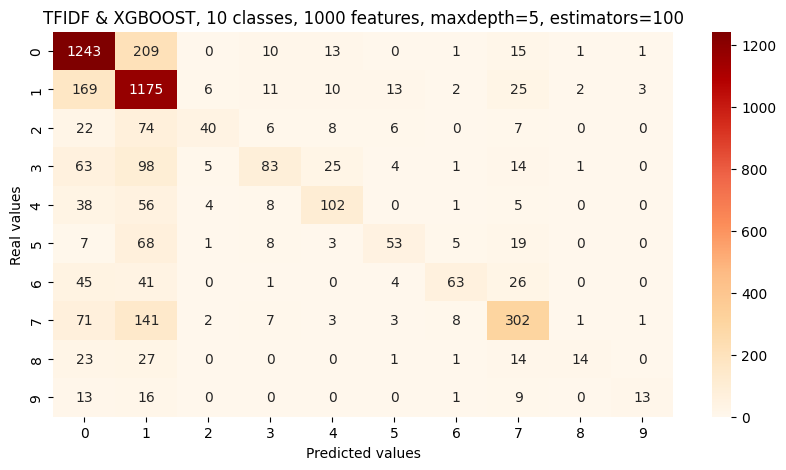

In [ ]:
#tfidf vectorizer, then XGB, all 10 classes

pipeline = Pipeline([
    ('tfid', TfidfVectorizer(max_features=1000)),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test))
plot_confusion_matrix(Y_test,Y_pred_test, "TFIDF & XGBOOST, 10 classes, 1000 features, maxdepth=5, estimators=100", [0,1,2,3,4,5,6,7,8,9])

/home/wiktmm/uni/mpum/Genre-Classificator/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:21:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training set results:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78      5970
           1       0.63      0.84      0.72      5663
           2       0.97      0.39      0.56       654
           3       0.88      0.39      0.54      1177
           4       0.79      0.54      0.64       856
           5       0.97      0.41      0.58       657
           6       0.89      0.42      0.57       718
           7       0.75      0.65      0.70      2158
           8       0.97      0.22      0.36       320
           9       1.00      0.20      0.33       207

    accuracy                           0.71     18380
   macro avg       0.86      0.49      0.58     18380
weighted avg       0.75      0.71      0.70     18380

Test set results:
              precision    recall  f1-score   support

           0       0.66      0.79      0.71      1493
           1       0.56      0.78      0.65      1416
           2       0.35      0.07     

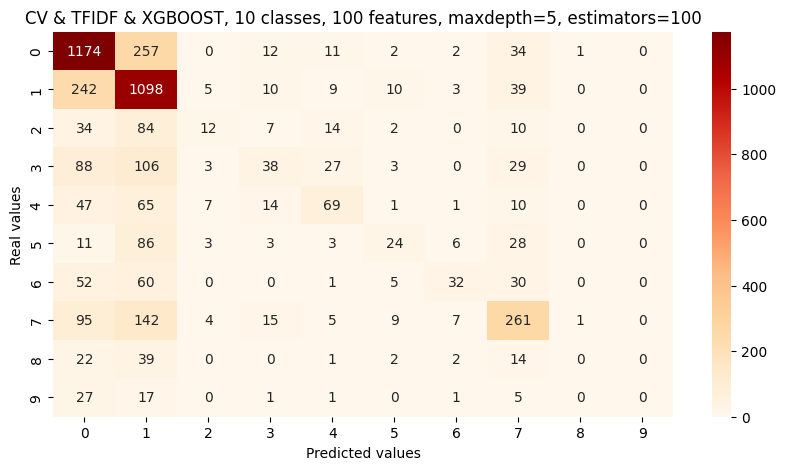

In [ ]:
#tfidf vectorizer, then XGB, all 10 classes

pipeline = Pipeline([ 
    ('tfid', TfidfVectorizer(max_features=100)),  
    ('model', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        use_label_encoder=False,
        eval_metric='mlogloss',
    ))
    ]
)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

pipeline.fit(X_train, Y_train)
Y_pred_test = pipeline.predict(X_test)
Y_pred_train = pipeline.predict(X_train)

print("Training set results:")
print(metrics.classification_report(Y_train, Y_pred_train))
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred_test, zero_division=0))
plot_confusion_matrix(Y_test,Y_pred_test, "CV & TFIDF & XGBOOST, 10 classes, 100 features, maxdepth=5, estimators=100", [0,1,2,3,4,5,6,7,8,9])